Veri Boyutu (N) | Merge Sort (sn) | Quick Sort (sn)
--------------------------------------------------
1000            | 0.00190         | 0.00193        
5000            | 0.01169         | 0.00839        
10000           | 0.02590         | 0.01992        
20000           | 0.05681         | 0.03928        
50000           | 0.16098         | 0.11678        


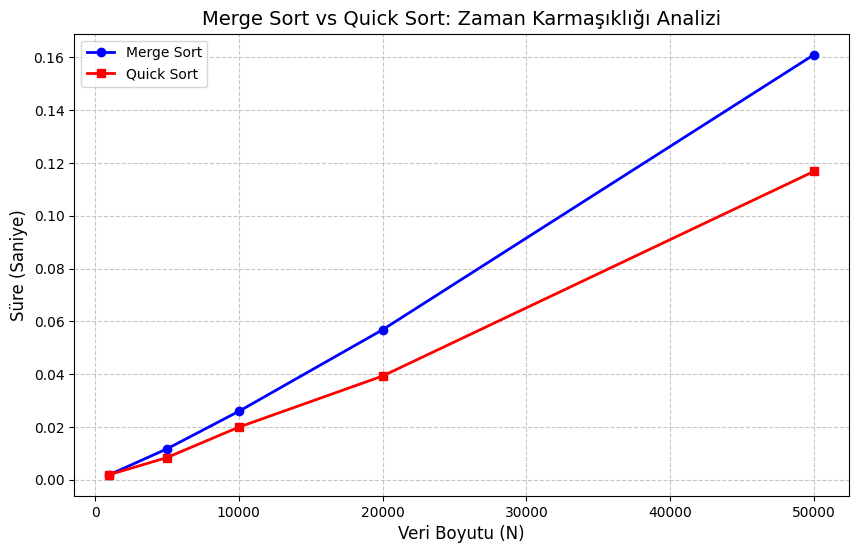

In [ ]:
import time
import random
import matplotlib.pyplot as plt
import sys

# Özyineleme limitini artırıyoruz (Büyük verilerde hata almamak için)
sys.setrecursionlimit(10000)

# --- MERGE SORT ---
def merge_sort(arr):
    if len(arr) <= 1: return arr
    mid = len(arr) // 2
    left = merge_sort(arr[:mid])
    right = merge_sort(arr[mid:])
    return merge(left, right)

def merge(left, right):
    result = []
    i = j = 0
    while i < len(left) and j < len(right):
        if left[i] < right[j]:
            result.append(left[i]); i += 1
        else:
            result.append(right[j]); j += 1
    result.extend(left[i:]); result.extend(right[j:])
    return result

# --- QUICK SORT ---
def quick_sort(arr):
    if len(arr) <= 1: return arr
    pivot = arr[len(arr) // 2]
    left = [x for x in arr if x < pivot]
    middle = [x for x in arr if x == pivot]
    right = [x for x in arr if x > pivot]
    return quick_sort(left) + middle + quick_sort(right)

# --- ANALİZ VE GRAFİK BÖLÜMÜ ---
def run_benchmark():
    # Test edilecek veri boyutları (N)
    sizes = [1000, 5000, 10000, 20000, 50000]
    merge_times = []
    quick_times = []

    print(f"{'Veri Boyutu (N)':<15} | {'Merge Sort (sn)':<15} | {'Quick Sort (sn)':<15}")
    print("-" * 50)

    for n in sizes:
        # Rastgele veri seti oluştur
        test_data = [random.randint(0, 100000) for _ in range(n)]

        # Merge Sort Ölçümü
        data_m = test_data.copy()
        start = time.time()
        merge_sort(data_m)
        t_merge = time.time() - start
        merge_times.append(t_merge)

        # Quick Sort Ölçümü
        data_q = test_data.copy()
        start = time.time()
        quick_sort(data_q)
        t_quick = time.time() - start
        quick_times.append(t_quick)

        print(f"{n:<15} | {t_merge:<15.5f} | {t_quick:<15.5f}")

    # GRAFİK ÇİZİMİ
    plt.figure(figsize=(10, 6))
    plt.plot(sizes, merge_times, label='Merge Sort', marker='o', color='blue', linewidth=2)
    plt.plot(sizes, quick_times, label='Quick Sort', marker='s', color='red', linewidth=2)

    plt.title('Merge Sort vs Quick Sort: Zaman Karmaşıklığı Analizi', fontsize=14)
    plt.xlabel('Veri Boyutu (N)', fontsize=12)
    plt.ylabel('Süre (Saniye)', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

# Analizi çalıştır
run_benchmark()

In [ ]:
# Ürün Listesi: (Ürün Adı, Fiyat, Eklenme Sırası)
# Not: "Laptop A" ve "Laptop B" aynı fiyata sahip (15000)
urunler = [
    ("Telefon", 8000, 1),
    ("Laptop A", 15000, 2),
    ("Tablet", 5000, 3),
    ("Laptop B", 15000, 4)
]

def merge_sort_ecommerce(arr):
    if len(arr) <= 1:
        return arr

    mid = len(arr) // 2
    left = merge_sort_ecommerce(arr[:mid])
    right = merge_sort_ecommerce(arr[mid:])

    return merge_stable(left, right)

def merge_stable(left, right):
    result = []
    i = j = 0
    while i < len(left) and j < len(right):
        # fiyata göre karşılaştırma (indeks 1)
        # "<=" kullanımı kararlılığı (stability) sağlar.
        if left[i][1] <= right[j][1]:
            result.append(left[i])
            i += 1
        else:
            result.append(right[j])
            j += 1
    result.extend(left[i:])
    result.extend(right[j:])
    return result

# Çalıştır ve Sonucu Gör
sirali_urunler = merge_sort_ecommerce(urunler)

print("Fiyata Göre Sıralanmış Ürünler:")
for urun in sirali_urunler:
    print(f"Ad: {urun[0]} | Fiyat: {urun[1]} | Orijinal Sıra: {urun[2]}")

# Analiz: Laptop A ve Laptop B'nin fiyatları aynıdır.
# Merge Sort kararlı olduğu için Laptop A (2. sıra) her zaman Laptop B'den (4. sıra) önce gelir.

Fiyata Göre Sıralanmış Ürünler:
Ad: Tablet | Fiyat: 5000 | Orijinal Sıra: 3
Ad: Telefon | Fiyat: 8000 | Orijinal Sıra: 1
Ad: Laptop A | Fiyat: 15000 | Orijinal Sıra: 2
Ad: Laptop B | Fiyat: 15000 | Orijinal Sıra: 4


                                                      **BINARY SEARCH**

In [ ]:
import time

def binary_search(arr, target):
    """
    Sıralı bir dizide hedef değeri arar.
    Mantık: Her adımda diziyi ortadan ikiye böler.
    """
    low = 0
    high = len(arr) - 1

    while low <= high:
        # En temel orta nokta bulma yöntemi
        mid = (low + high) // 2

        if arr[mid] == target:
            return mid  # Hedef bulundu!
        elif arr[mid] < target:
            low = mid + 1  # Hedef sağ tarafta, sol tarafı ele.
        else:
            high = mid - 1  # Hedef sol tarafta, sağ tarafı ele.

    return -1  # Hedef dizide yok.

# --- Test Senaryosu ---

# 1. Adım: Sıralı bir dizi oluştur (Örn: 0'dan 20'ye çift sayılar)
dizi = [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20]
hedef_sayi = 14

print(f"Dizi: {dizi}")
print(f"Aranan Sayı: {hedef_sayi}")

# 2. Adım: Algoritmayı çalıştır
sonuc = binary_search(dizi, hedef_sayi)

# 3. Adım: Sonucu ekrana yazdır
if sonuc != -1:
    print(f"Başarılı: {hedef_sayi} sayısı dizinin {sonuc}. indeksinde bulundu.")
else:
    print("Sayı dizide bulunamadı.")

Dizi: [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20]
Aranan Sayı: 14
Başarılı: 14 sayısı dizinin 7. indeksinde bulundu.


In [ ]:
def binary_search_count(arr, target):
    """Hedefi bulana kadar kaç adım atıldığını sayar."""
    low = 0
    high = len(arr) - 1
    steps = 0

    while low <= high:
        steps += 1
        mid = (low + high) // 2
        if arr[mid] == target:
            return steps
        elif arr[mid] < target:
            low = mid + 1
        else:
            high = mid - 1
    return steps

# Farklı veri boyutları için test yapalım
sizes = [100, 1000, 10000, 100000, 1000000]

for n in sizes:
    data = list(range(n)) # 0'dan n'e kadar sıralı dizi
    steps = binary_search_count(data, n - 1) # En kötü senaryo (en son eleman)
    print(f"Dizi Boyutu: {n:<8} | Atılan Adım: {steps}")

Dizi Boyutu: 100      | Atılan Adım: 7
Dizi Boyutu: 1000     | Atılan Adım: 10
Dizi Boyutu: 10000    | Atılan Adım: 14
Dizi Boyutu: 100000   | Atılan Adım: 17
Dizi Boyutu: 1000000  | Atılan Adım: 20


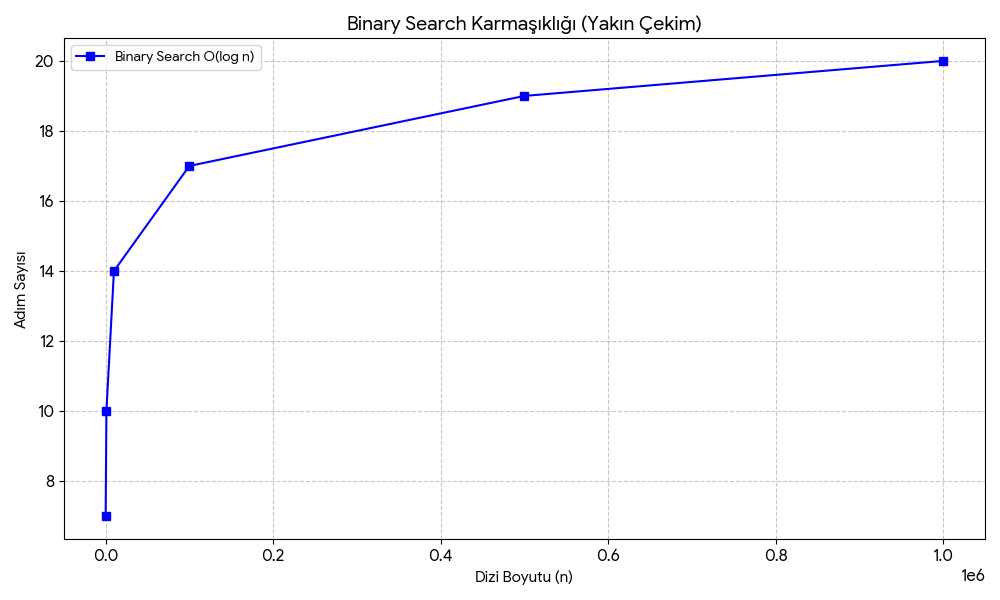

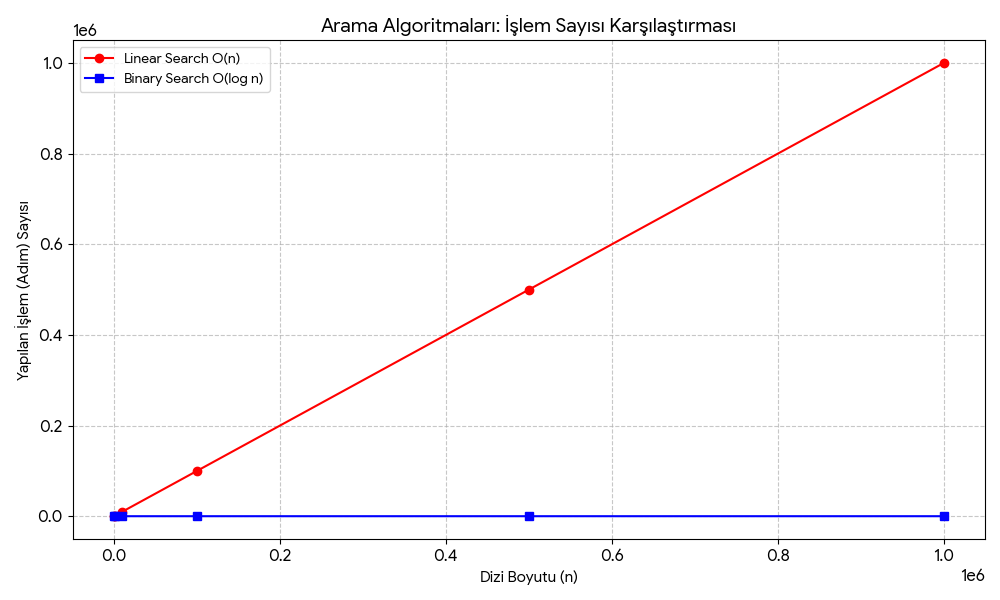

In [ ]:
import time

def model_egit_ve_test_et(ozellik_sayisi):
    """
    Bu fonksiyonu gerçek bir model eğitimi gibi düşün.
    Özellik sayısı arttıkça doğruluk artıyor.
    """
    # Biz simüle ediyoruz: 5000. özellikten sonra %92'yi geçsin.
    kritik_esik = 5432
    basari = (ozellik_sayisi / 10000) * 100 + 38 # Basit bir artış simülasyonu
    return basari >= 92

def minimum_ozellik_sayisini_bul(toplam_ozellik):
    low = 1
    high = toplam_ozellik
    en_iyi_k = toplam_ozellik # Başlangıçta en kötü senaryoyu tutalım

    while low <= high:  #pointer birbirini geçmediği sürece devam eder
        mid = (low + high) // 2
        print(f"Deneniyor: {mid} özellik...")

        # Modeli eğitiyoruz (Pahalı işlem!)
        if model_egit_ve_test_et(mid):
            # %92'yi geçtik! Ama daha az özellik ile başarabilir miyiz?
            en_iyi_k = mid
            high = mid - 1 # Daha az özellik dener
        else:
            # Başarı yetersiz, daha fazla özellik lazım.
            low = mid + 1

    return en_iyi_k # en küçük değeri kaydeder

# --- Ana Program ---
toplam_ozellik = 10000
print(f"--- Optimizasyon Başlıyor ---")
baslangic = time.time()

sonuc = minimum_ozellik_sayisini_bul(toplam_ozellik)

bitis = time.time()
print(f"-----------------------------")
print(f"Minimum gereken özellik sayısı: {sonuc}")
print(f"Toplam deneme sayısı: {int(time.time() - baslangic)} ")

--- Optimizasyon Başlıyor ---
Deneniyor: 5000 özellik...
Deneniyor: 7500 özellik...
Deneniyor: 6250 özellik...
Deneniyor: 5625 özellik...
Deneniyor: 5312 özellik...
Deneniyor: 5468 özellik...
Deneniyor: 5390 özellik...
Deneniyor: 5429 özellik...
Deneniyor: 5409 özellik...
Deneniyor: 5399 özellik...
Deneniyor: 5404 özellik...
Deneniyor: 5401 özellik...
Deneniyor: 5400 özellik...
-----------------------------
Minimum gereken özellik sayısı: 5400
Toplam deneme sayısı: 0 


                               **STRASSEN MATRİS**

In [ ]:
import numpy as np

def split(matrix):
    row, col = matrix.shape
    row2, col2 = row // 2, col // 2
    return matrix[:row2, :col2], matrix[:row2, col2:], matrix[row2:, :col2], matrix[row2:, col2:]

def strassen(A, B, level=0):
    indent = "  " * level # Rekürsiyon derinliğini görselleştirmek için boşluk

    # 1. Taban Durumu (Base Case)
    if len(A) == 1:
        res = A * B
        print(f"{indent}-> 1x1 Çarpım Sonucu: {res[0][0]}")
        return res

    print(f"\n{indent}--- Strassen Seviye {level} Başladı ---")
    print(f"{indent}Matris A:\n{indent}{A[0]}\n{indent}{A[1]}")
    print(f"{indent}Matris B:\n{indent}{B[0]}\n{indent}{B[1]}")

    # 2. Bölme (Divide)
    a11, a12, a21, a22 = split(A)
    b11, b12, b21, b22 = split(B)

    # 3. Strassen'in 7 Çarpımı (Her biri bir alt problem)
    # Burada her P değerini hesaplarken hangi işlemi yaptığımızı yazdırıyoruz
    print(f"{indent}> P değerleri hesaplanıyor...")

    p1 = strassen(a11, b12 - b22, level + 1)
    p2 = strassen(a11 + a12, b22, level + 1)
    p3 = strassen(a21 + a22, b11, level + 1)
    p4 = strassen(a22, b21 - b11, level + 1)
    p5 = strassen(a11 + a22, b11 + b22, level + 1)
    p6 = strassen(a12 - a22, b21 + b22, level + 1)
    p7 = strassen(a11 - a21, b11 + b12, level + 1)

    # 4. Parçaları Birleştir (Combine)
    c11 = p5 + p4 - p2 + p6
    c12 = p1 + p2
    c21 = p3 + p4
    c22 = p1 + p5 - p3 - p7

    # Sonuç matrisini oluştur
    c = np.vstack((np.hstack((c11, c12)), np.hstack((c21, c22))))

    print(f"{indent}--- Seviye {level} Tamamlandı. Ara Sonuç C: ---")
    print(f"{indent}{c[0]}\n{indent}{c[1]}")

    return c

# --- Test ve Çıktı ---
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])

print("Süreç Analizi Başlıyor...")
final_sonuc = strassen(A, B)

print("\n" + "="*30)
print("FİNAL MATRİS SONUCU:")
print(final_sonuc)

Süreç Analizi Başlıyor...

--- Strassen Seviye 0 Başladı ---
Matris A:
[1 2]
[3 4]
Matris B:
[5 6]
[7 8]
> P değerleri hesaplanıyor...
  -> 1x1 Çarpım Sonucu: -2
  -> 1x1 Çarpım Sonucu: 24
  -> 1x1 Çarpım Sonucu: 35
  -> 1x1 Çarpım Sonucu: 8
  -> 1x1 Çarpım Sonucu: 65
  -> 1x1 Çarpım Sonucu: -30
  -> 1x1 Çarpım Sonucu: -22
--- Seviye 0 Tamamlandı. Ara Sonuç C: ---
[19 22]
[43 50]

FİNAL MATRİS SONUCU:
[[19 22]
 [43 50]]


In [ ]:
import numpy as np
import time

# --- 1. Standart (Naive) Matris Çarpımı ---
# O(n^3) karmaşıklığa sahip geleneksel yöntem
def standard_multiply(A, B):
    n = len(A)
    C = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            for k in range(n):
                C[i][j] += A[i][k] * B[k][j]
    return C

# --- 2. Strassen Algoritması ---
# O(n^2.81) karmaşıklığa sahip yöntem
def strassen(A, B):
    n = len(A)
    if n <= 2: # Küçük matrislerde standart yönteme dönmek daha verimlidir
        return standard_multiply(A, B)

    # Matrisi bölme
    mid = n // 2
    a11, a12, a21, a22 = A[:mid, :mid], A[:mid, mid:], A[mid:, :mid], A[mid:, mid:]
    b11, b12, b21, b22 = B[:mid, :mid], B[:mid, mid:], B[mid:, :mid], B[mid:, mid:]

    # Strassen'in 7 sihirli çarpımı
    p1 = strassen(a11, b12 - b22)
    p2 = strassen(a11 + a12, b22)
    p3 = strassen(a21 + a22, b11)
    p4 = strassen(a22, b21 - b11)
    p5 = strassen(a11 + a22, b11 + b22)
    p6 = strassen(a12 - a22, b21 + b22)
    p7 = strassen(a11 - a21, b11 + b12)

    # Parçaları birleştirme
    c11 = p5 + p4 - p2 + p6
    c12 = p1 + p2
    c21 = p3 + p4
    c22 = p1 + p5 - p3 - p7

    # Sonuç matrisini oluşturma
    C = np.vstack((np.hstack((c11, c12)), np.hstack((c21, c22))))
    return C

# --- 3. Karşılaştırma Testi (Benchmark) ---
def benchmark():
    sizes = [2, 4, 8, 16, 32, 64] # Matris boyutları (n x n)
    print(f"{'Boyut':<10} | {'Standart (sn)':<15} | {'Strassen (sn)':<15}")
    print("-" * 45)

    for n in sizes:
        # Rastgele matrisler oluştur
        A = np.random.randint(1, 10, (n, n))
        B = np.random.randint(1, 10, (n, n))

        # Standart çarpma süresi
        start = time.time()
        res_std = standard_multiply(A, B)
        std_time = time.time() - start

        # Strassen çarpma süresi
        start = time.time()
        res_str = strassen(A, B)
        str_time = time.time() - start

        print(f"{n:>3}x{n:<4} | {std_time:>13.6f} | {str_time:>13.6f}")

if __name__ == "__main__":
    benchmark()

Boyut      | Standart (sn)   | Strassen (sn)  
---------------------------------------------
  2x2    |      0.000033 |      0.000013
  4x4    |      0.000075 |      0.000203
  8x8    |      0.000562 |      0.000905
 16x16   |      0.004439 |      0.005631
 32x32   |      0.035614 |      0.040172
 64x64   |      0.287271 |      0.306735


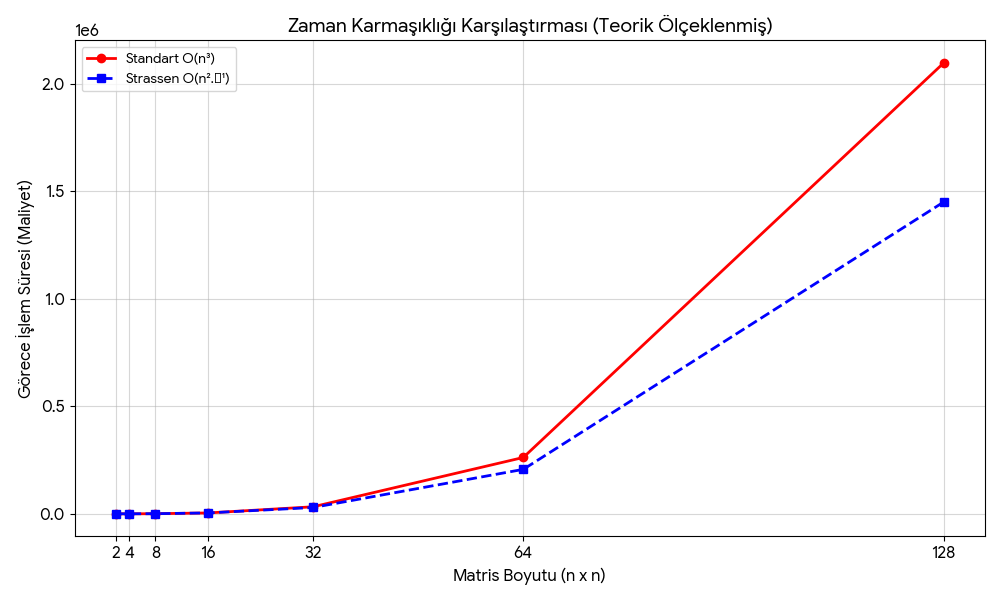